Based on [this notebook](https://colab.research.google.com/drive/1lD675HGWXQOktPXSPUOmipMj3EkPCbJs?usp=sharing)

# Simple Linear Regression using Dask

This notebook demonstrates the use of Dask for scalable data processing and machine learning. The workflow includes generating synthetic taxi fare data, preprocessing it using Dask arrays and dataframes, and training a linear regression model to predict taxi fares. The notebook also showcases the use of a distributed computing cluster for efficient computation and evaluates the model's performance using Mean Squared Error (MSE). Visualization of the results is provided to compare predicted and actual fare amounts.

The next cell installs the required Python packages for this notebook. It uses the `%pip install` magic command to install `dask[complete]` for scalable data processing, `scikit-learn` for machine learning, and `dask-ml` for machine learning extensions in Dask. These packages are essential for the workflow demonstrated in this notebook. 


In [1]:
%pip install dask[complete] scikit-learn dask-ml


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Libraries import

The next cell imports the necessary libraries for this notebook. It imports Dask's array and dataframe modules (`dask.array` and `dask.dataframe`) for scalable data processing, the `numpy` library for numerical operations, and the `train_test_split`, `LinearRegression`, and `mean_squared_error` functions from Dask's machine learning module (`dask_ml`) for model training and evaluation. The `np.random.seed` function is used to set a random seed for reproducibility of the results.

In [2]:
import dask.array as da
import dask.dataframe as dd
import numpy as np
from dask_ml.model_selection import train_test_split
from dask_ml.linear_model import LinearRegression
from dask_ml.metrics import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

n_workers = 20

### Initializing Dask cluster and client
The next cell initializes a Dask cluster and client for distributed computing. The `Client` object is created to manage the cluster and enable parallel computation. 

In [3]:
from dask_jobqueue import SGECluster

job_script_prologue = [
    "source /afs/crc.nd.edu/user/a/akuehlka/.bashrc",
    "source /afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/bin/activate"
]

cluster = SGECluster(
    name = "dask-worker",
    cores = 1,
    processes = 1,
    memory = "2GB",
    local_directory = "/tmp",
    queue = "long",
    job_script_prologue=job_script_prologue
)
# print(cluster.job_script())
cluster.scale(n_workers)


from dask.distributed import Client
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SGECluster
Dashboard: http://10.32.85.47:8787/status,
Dashboard: http://10.32.85.47:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.32.85.47:46659,Workers: 0
Dashboard: http://10.32.85.47:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Generating synthetic taxi fare data

The next cell generates synthetic taxi fare data using the `numpy` library. It creates a dataset with 1,000,000 samples, where each sample consists of features such as trip distance, passenger count, and fare amount. The fare amount is generated using a linear equation with some added noise to simulate real-world data. The generated data is then converted into a Dask dataframe for scalable processing.

In [4]:
# Generate data
size = 1_000_000
passenger_count = da.from_array(np.random.randint(1, 6, size), chunks=(size // n_workers,))
trip_distance = da.from_array(np.random.uniform(0.5, 20, size), chunks=(size // n_workers,))
fare_amount = 0.50 * (passenger_count - 1) + 1.50 * trip_distance + 2.50
# Add noise
fare_amount = fare_amount + da.random.normal(0, 0.05 * fare_amount)


### Inspect the data
The next cells inspect the distributed arrays to understand its structure. It also checks the data types of each column to ensure they are appropriate for further processing.

In [5]:
passenger_count

dask.array<array, shape=(1000000,), dtype=int64, chunksize=(50000,), chunktype=numpy.ndarray>

In [6]:
trip_distance

dask.array<array, shape=(1000000,), dtype=float64, chunksize=(50000,), chunktype=numpy.ndarray>

In [7]:
fare_amount

dask.array<add, shape=(1000000,), dtype=float64, chunksize=(50000,), chunktype=numpy.ndarray>

# Combine distributed arrays into a distributed Dask dataframe
The next cell combines the distributed arrays into a Dask dataframe. This allows us to handle data in a table format, making it easier to manipulate and analyze. The dataframe is created with appropriate column names for the features and target variable.


In [8]:
# Stack Dask arrays into a single 2D array
data = da.stack([passenger_count, trip_distance, fare_amount], axis=1)

# Create Dask DataFrame
df = dd.from_dask_array(
    data, 
    columns=["passenger_count", "trip_distance", "fare_amount"],
)

df.head(5)

/afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/lib/python3.12/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 15.32 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


,passenger_count,trip_distance,fare_amount
0,4.0,12.670732,22.380482
1,5.0,9.163611,17.784958
2,3.0,16.903713,31.580780
3,5.0,6.843757,15.336414
4,5.0,15.432010,27.618961


### Splitting the data into training and testing sets
The next cell splits the data into training and testing sets using the `train_test_split` function from Dask's machine learning module. 

In [11]:

# Split the dataset into training and testing sets
X = df[["passenger_count", "trip_distance"]]
y = df["fare_amount"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Outputs are Dask DataFrames, which we need to convert to Dask arrays
X_train_array = X_train.to_dask_array(lengths=True)
y_train_array = y_train.to_dask_array(lengths=True)
X_test_array = X_test.to_dask_array(lengths=True)
y_test_array = y_test.to_dask_array(lengths=True)


/afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/lib/python3.12/site-packages/dask_ml/model_selection/_split.py:464: FutureWarning: The default value for 'shuffle' must be specified when splitting DataFrames. In the future DataFrames will automatically be shuffled within blocks prior to splitting. Specify 'shuffle=True' to adopt the future behavior now, or 'shuffle=False' to retain the previous behavior.
  warnings.warn(
/afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/lib/python3.12/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 15.37 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/lib/python3.12/site-packages/distributed/client.py:3383: UserW

### Fitting the linear regression model
The next cell fits a linear regression model to the training data using the `LinearRegression` class from Dask's machine learning module. The model is trained on the features and target variable from the training set.

In [12]:
# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train_array, y_train_array)

# Make predictions on the test set
y_pred_array = model.predict(X_test_array)


/afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/lib/python3.12/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 15.40 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/lib/python3.12/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 15.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/lib/python3.12/site-packages/distributed/cli

### Evaluating the model
The next cell evaluates the model's performance on the testing set. It uses the `mean_squared_error` function from Dask's machine learning module to calculate the Mean Squared Error (MSE) between the predicted and actual fare amounts. The MSE is a common metric for regression tasks, indicating how well the model performs.

In [13]:
# Evaluate the model using Mean Squared Error (MSE)
mse = mean_squared_error(y_test_array, y_pred_array)
print(f"Mean Squared Error: {mse:.2f}")

# (Optional) Display model coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


/afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/lib/python3.12/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 15.46 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Mean Squared Error: 1.06
Coefficients: [0.49979651 1.49989485]
Intercept: 2.0008240800060335


### Comparing predicted and actual fare amounts
The next cell compares the predicted and actual fare amounts by plotting them using the `matplotlib` library. The plot visualizes the relationship between the predicted and actual values, providing insights into the model's performance.

/afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/lib/python3.12/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 15.40 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/afs/crc.nd.edu/user/a/akuehlka/src/workshop_dask/.venv/lib/python3.12/site-packages/distributed/client.py:3383: UserWarning: Sending large graph of size 15.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


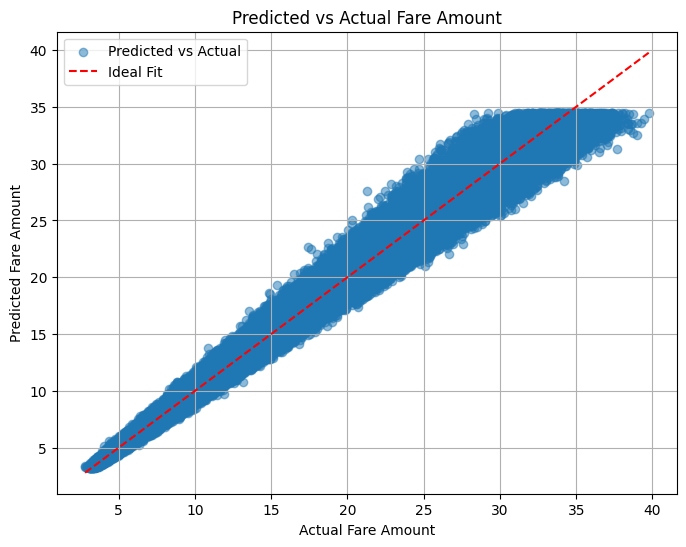

In [14]:
import matplotlib.pyplot as plt

# Compute the predicted and actual fare amounts
y_pred = y_pred_array.compute()
y_test = y_test_array.compute()

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Ideal Fit")
plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Predicted vs Actual Fare Amount")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
cluster.close()